Upload the COVID-19 Dataset to Files and change DATA_PATH to whatever the name of the file is in order for the code to run properly. Once this is done, it should not take very long for all of the code to run.

In [47]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import chi2_contingency
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore") #makes outputs cleaner

In [48]:
DATA_PATH = "COVID Dataset.csv" #Change to whatever the file is named as
CUTOFF_DATE = "2022-01-01" #Play with as needed to test out certain dates as train/test split date
REGION_NAME_MAP = {
    "Asia": "Asia",
    "Africa": "Africa",
    "Europe": "Europe",
    "North America": "North America",
    "South America": "South America",
    "Australia": "Australia",
} #Feel free to add more regions to this dictionary if you want to test this script on a specific country or the world

ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 7) #gives set parameters at start of script that do not change.
# feel free to alter as needed. Values were chosen when considering this is COVID data updated daily. Weekly seasonality

OUTPUT_DIR = "covid_analysis_outputs"
EDA_DIR = os.path.join(OUTPUT_DIR, "eda_plots")
FORECAST_DIR = os.path.join(OUTPUT_DIR, "forecast_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)
os.makedirs(FORECAST_DIR, exist_ok=True)

#These 3 lines help store all visualizations and tables so code does not need to be re-run to obtain results again


In [49]:
df = pd.read_csv(DATA_PATH) # loads in data


df["Day"] = pd.to_datetime(df["Day"], errors="coerce")
df["Cases"] = pd.to_numeric(df["Cases"], errors="coerce")
df["Deaths"] = pd.to_numeric(df["Deaths"], errors="coerce")
#ensures proper format of data

df = df.dropna(subset=["Day"]).copy()
#removes columns without a valid date

df = df.sort_values(["Entity", "Day"]).reset_index(drop=True)
#sort alphabetically first then by date

df["Cases_7day"] = (
    df["Cases"]
)#more descriptive column name because this is a 7 day rolling average

df["Deaths_7day"] = (
    df["Deaths"]
)#more descriptive column name because this is a 7 day rolling average


In [50]:
df

,Entity,Code,Day,Deaths,Cases,Cases_7day,Deaths_7day
0,Afghanistan,AFG,2020-01-09,0.0,0.0,0.0,0.0
1,Afghanistan,AFG,2020-01-10,0.0,0.0,0.0,0.0
2,Afghanistan,AFG,2020-01-11,0.0,0.0,0.0,0.0
3,Afghanistan,AFG,2020-01-12,0.0,0.0,0.0,0.0
4,Afghanistan,AFG,2020-01-13,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
550682,Zimbabwe,ZWE,2026-02-04,0.0,0.0,0.0,0.0
550683,Zimbabwe,ZWE,2026-02-05,0.0,0.0,0.0,0.0
550684,Zimbabwe,ZWE,2026-02-06,0.0,0.0,0.0,0.0
550685,Zimbabwe,ZWE,2026-02-07,0.0,0.0,0.0,0.0


In [51]:
def get_region_df(data, region_label): #verifies that an entity exists and extracts the data for that entity
    region_df = data[data["Entity"] == region_label].copy()
    if region_df.empty:
        raise ValueError(f"No rows found for Entity == '{region_label}'.")
    return region_df

In [52]:
def plot_regional_rolling_cases(data, region_map): # plots the cases data for a region over time. line plot
    plt.figure(figsize=(12, 6))

    for display_name, entity_name in region_map.items():
        region_df = get_region_df(data, entity_name).copy()
        region_df = region_df.sort_values("Day")
        plt.plot(
            region_df["Day"],
            region_df["Cases_7day"],
            label=display_name,
            linewidth=1.5
        ) #makes visualization

    plt.title("Daily COVID-19 Cases by Continent (7-Day Rolling Average)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("New Cases", fontsize=12)
    plt.legend(title="Region", loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(visible=True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    outpath = os.path.join(EDA_DIR, "exploratory_regional_cases_trends.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight") #saves visualization
    plt.show()

In [53]:
def plot_regional_rolling_deaths(data, region_map): # plots the deaths data for a region region over time. line plot
    plt.figure(figsize=(12, 6))

    for display_name, entity_name in region_map.items():
        region_df = get_region_df(data, entity_name).copy()
        region_df = region_df.sort_values("Day")
        plt.plot(
            region_df["Day"],
            region_df["Deaths_7day"],
            label=display_name,
            linewidth=1.5
        ) #makes visualization

    plt.title("Daily COVID-19 Deaths by Continent (7-Day Rolling Average)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("New Deaths", fontsize=12)
    plt.legend(title="Region", loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(visible=True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    outpath = os.path.join(EDA_DIR, "exploratory_regional_deaths_trends.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight") #saves visualization
    plt.show()


In [54]:
def plot_distribution_metrics(data): # creates two histograms showing the distribution of daily cases and deaths, using a log scale
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    sns.histplot(
        data["Cases"].dropna(),
        bins=50,
        kde=True,
        ax=ax1,
        color="skyblue"
    )
    ax1.set_title("Distribution of Daily Cases (Log Scale)", fontsize=13)
    ax1.set_xlabel("Number of Cases")
    ax1.set_yscale("log")

    sns.histplot(
        data["Deaths"].dropna(),
        bins=50,
        kde=True,
        ax=ax2,
        color="salmon"
    ) # makes the visualization
    ax2.set_title("Distribution of Daily Deaths (Log Scale)", fontsize=13)
    ax2.set_xlabel("Number of Deaths")
    ax2.set_yscale("log") # log scale

    plt.suptitle("Exploratory Data Analysis: Distribution of Primary Metrics", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    outpath = os.path.join(EDA_DIR, "exploratory_distribution_metrics.png")
    plt.savefig(outpath, dpi=300, bbox_inches="tight") # saves visualization
    plt.show()

In [55]:
def prepare_time_series(data,region_label, target_col): #prepares data for SARIMA analysis
    region_df = get_region_df(data, region_label)[["Day", target_col]].dropna().copy() #keeps one region and 1 column
    region_df = region_df.sort_values("Day").set_index("Day") # sorts by date (should alreeady be done but just in case)

    full_index = pd.date_range(
        start=region_df.index.min(),
        end=region_df.index.max(),
        freq="D"
    ) # creates index of all dates between start and end
    region_df = region_df.reindex(full_index) #reindex to include missing days

    region_df[target_col] = region_df[target_col].interpolate().ffill().bfill() #fill in NA values (shouldn't be any but just to be safe)

    return region_df[target_col] # return 1 region 1 column


In [56]:
def run_sarima_analysis(data, region_display_name, region_entity_name, target_col, cutoff_date = CUTOFF_DATE, order = ORDER, seasonal_order = SEASONAL_ORDER):
    series = prepare_time_series(data, region_entity_name, target_col)#use function to prepare for SARIMA fitting

    cutoff_date = pd.to_datetime(cutoff_date) #cutoff date as datetime

    train = series[series.index < cutoff_date]
    test = series[series.index >= cutoff_date]

    if len(train) < 30 or len(test) < 10:
        print(f"Skipping {region_display_name} - {target_col}: not enough train/test data.")
        return None

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ) #describe model

    results = model.fit(disp=False) # fit model

    forecast = results.forecast(steps=len(test)) # predict with model
    forecast.index = test.index

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    r2 = r2_score(test, forecast) #key measurement/value!!!!!!!!!

    diff = forecast - test
    avg_pred_minus_actual = diff.mean()
    total_pred_minus_actual = diff.sum()

    return {
        "region": region_display_name,
        "entity_name": region_entity_name,
        "target": target_col,
        "cutoff_date": cutoff_date,
        "train": train,
        "test": test,
        "forecast": forecast,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "avg_predicted_minus_actual": avg_pred_minus_actual,
        "total_predicted_minus_actual": total_pred_minus_actual,
        "model_results": results,
    }#returns a ton of data, feel free to use whatever you deem most interesting/important

In [57]:
def plot_forecast_result(result, save_dir): #plots the predicted cases/deaths, actual cases/deaths, and the cutoff date
    region = result["region"]
    target = result["target"]
    train = result["train"]
    test = result["test"]
    forecast = result["forecast"]
    cutoff_date = result["cutoff_date"]

    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Actual Test")
    plt.plot(forecast.index, forecast, label="Forecast")
    plt.axvline(cutoff_date, linestyle="--", label="Cutoff Date")# plot visualizaton

    plt.title(f"{region} - {target} SARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.tight_layout()

    filename = f"{region.replace(' ', '_')}_{target}_forecast.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")# save visualizations
    plt.show()

In [58]:
def run_all_regions(data, region_map, target_col, cutoff_date = CUTOFF_DATE, order = ORDER, seasonal_order = SEASONAL_ORDER, make_plots = True,):
    #runs SARIMA analysis on all regions and returns/saves results
    all_results = []#to store results

    target_dir = os.path.join(FORECAST_DIR, target_col)
    os.makedirs(target_dir, exist_ok=True)

    for region_display_name, region_entity_name in region_map.items():
        try:
            result = run_sarima_analysis(
                data=data,
                region_display_name=region_display_name,
                region_entity_name=region_entity_name,
                target_col=target_col,
                cutoff_date=cutoff_date,
                order=order,
                seasonal_order=seasonal_order,
            )#executes analysis on all regions!

            if result is not None:
                all_results.append(result)
                if make_plots:
                    plot_forecast_result(result, target_dir)

        except Exception as e:
            print(f"Error for {region_display_name} - {target_col}: {e}")

    return all_results # returns results

In [59]:
def results_to_dataframe(results_list):#returns results as data frame!
    rows = []#stores data
    for r in results_list:
        rows.append({
            "Region": r["region"],
            "Target": r["target"],
            "MAE": r["mae"],
            "RMSE": r["rmse"],
            "R2": r["r2"],
            "Avg_Predicted_minus_Actual": r["avg_predicted_minus_actual"],
            "Total_Predicted_minus_Actual": r["total_predicted_minus_actual"],
        })
    return pd.DataFrame(rows)

In [60]:
def chi_square_effectiveness(results_list): #does a framework for chi-squared analysis
    rows = []

    for r in results_list:
        diff = r["forecast"] - r["test"]
        better = int((diff > 0).sum()) # if they did better than predicted, its a better day
        worse = int((diff <= 0).sum()) # if they did worse than predicted, its a worse day

        rows.append({
            "Region": r["region"],
            "Better": better,
            "Worse": worse
        }) # sets up a table of 3 columns. region, better, worse, to use in a chi square test

    table = pd.DataFrame(rows)
    contingency = table[["Better", "Worse"]].values # contingency table of better/worse

    chi2, p, dof, expected = chi2_contingency(contingency)

    stats = {
        "chi2": chi2, # chi squared stat
        "p_value": p, # p value
        "dof": dof, # degree of freedom
        "expected_counts": expected # expected counts for region
    }

    return table, stats


In [61]:
def print_chi_square_results(title, table, stats): # prints all results
    print(title)
    print("\nContingency table:")
    print(table)
    print("\nChi-square test results:")
    print(f"Chi2: {stats['chi2']}")
    print(f"p-value: {stats['p_value']}")
    print(f"dof: {stats['dof']}")
    print("\nExpected counts:")
    print(stats["expected_counts"])



Running EDA plots...


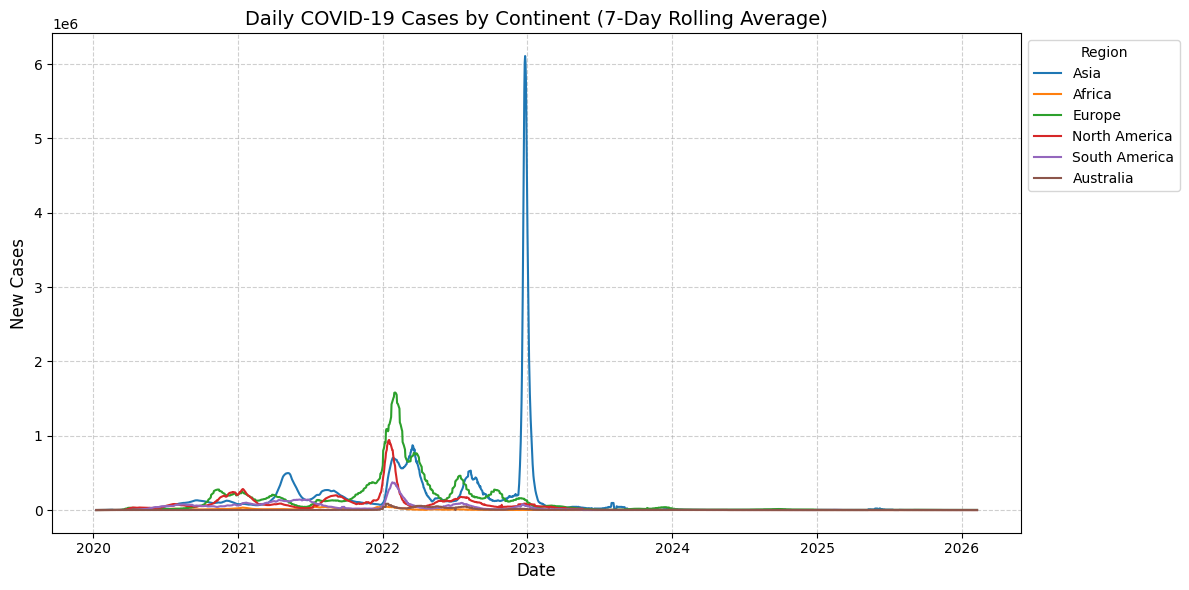

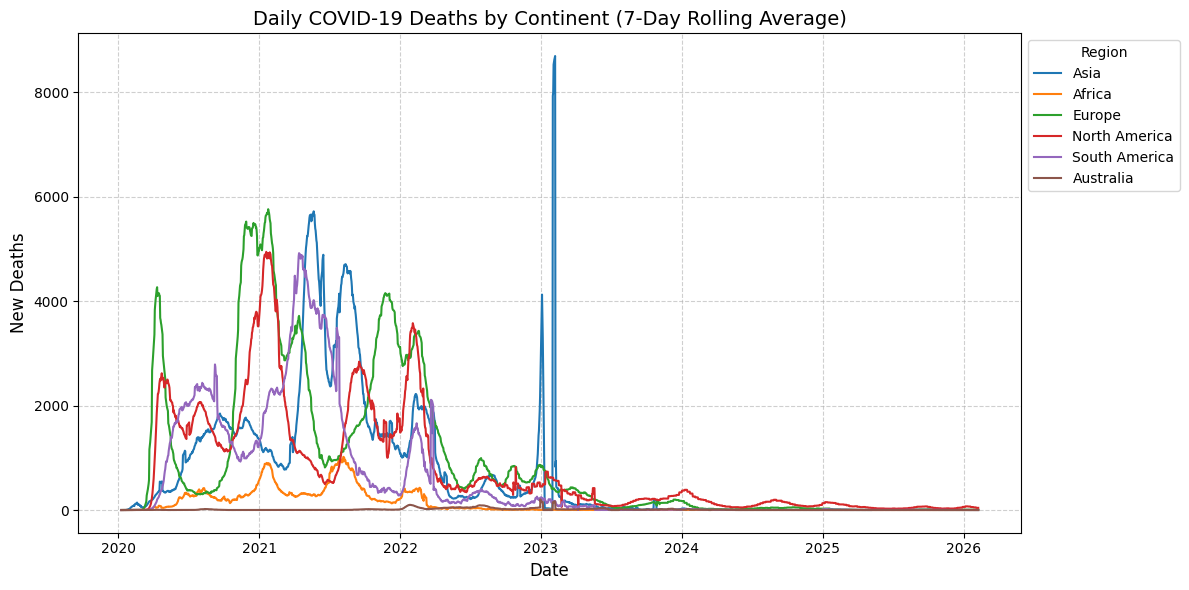

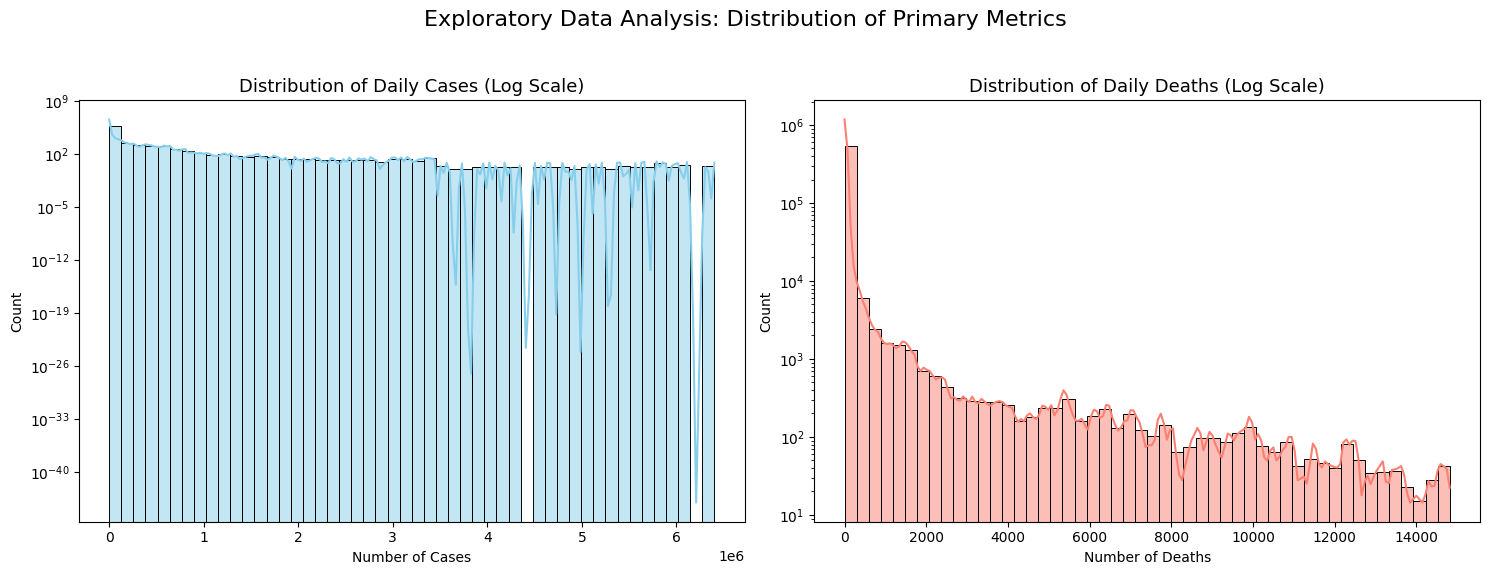


Running SARIMA for cases...


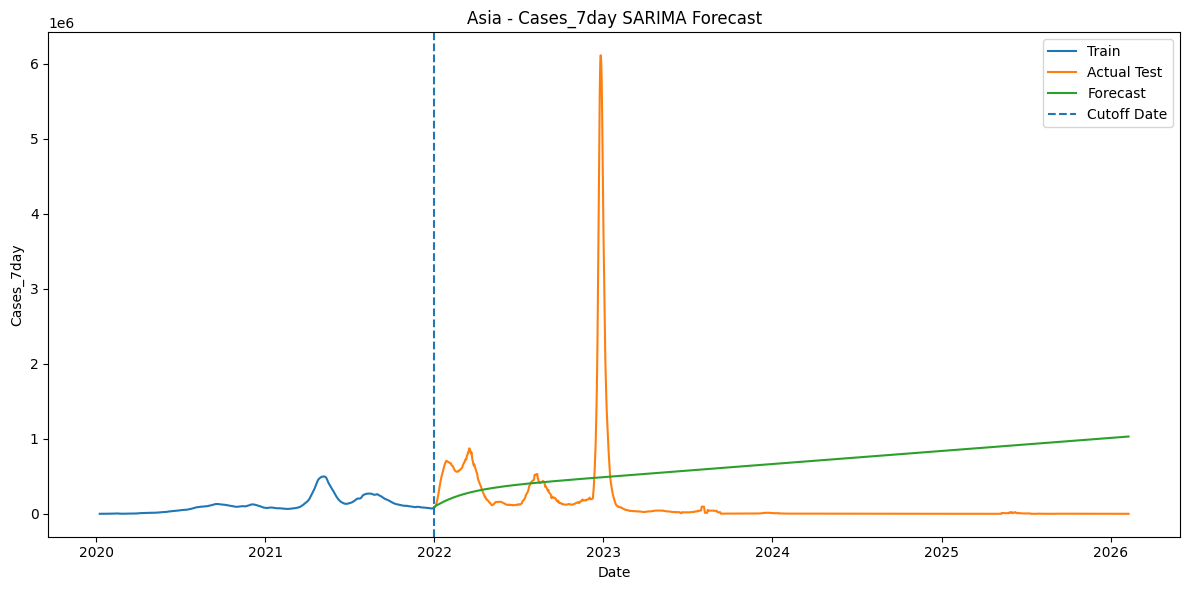

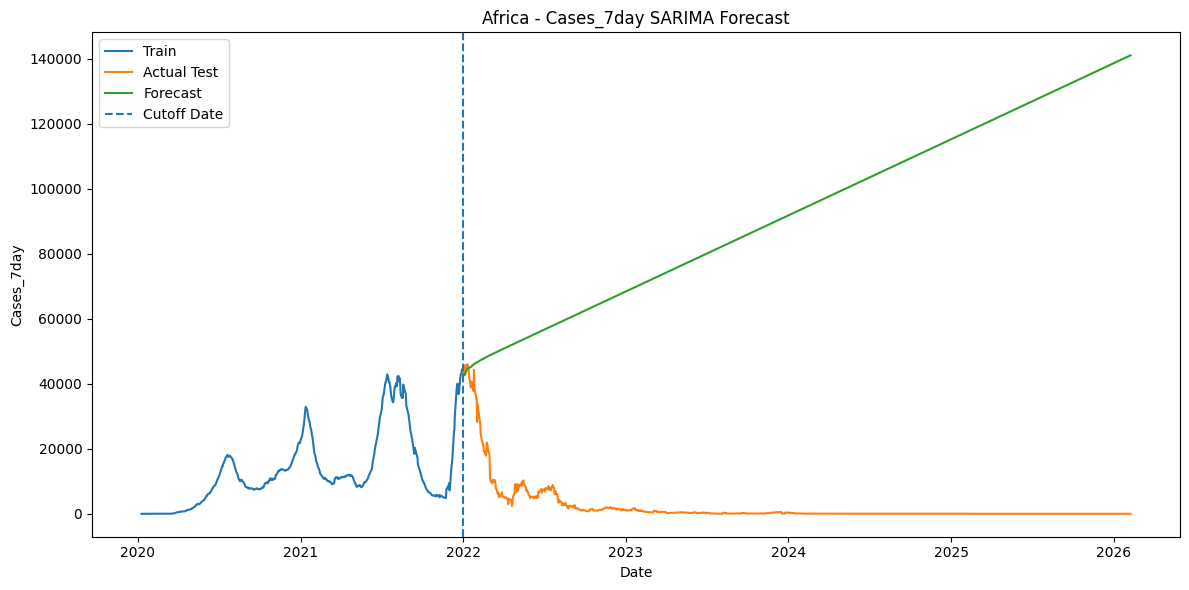

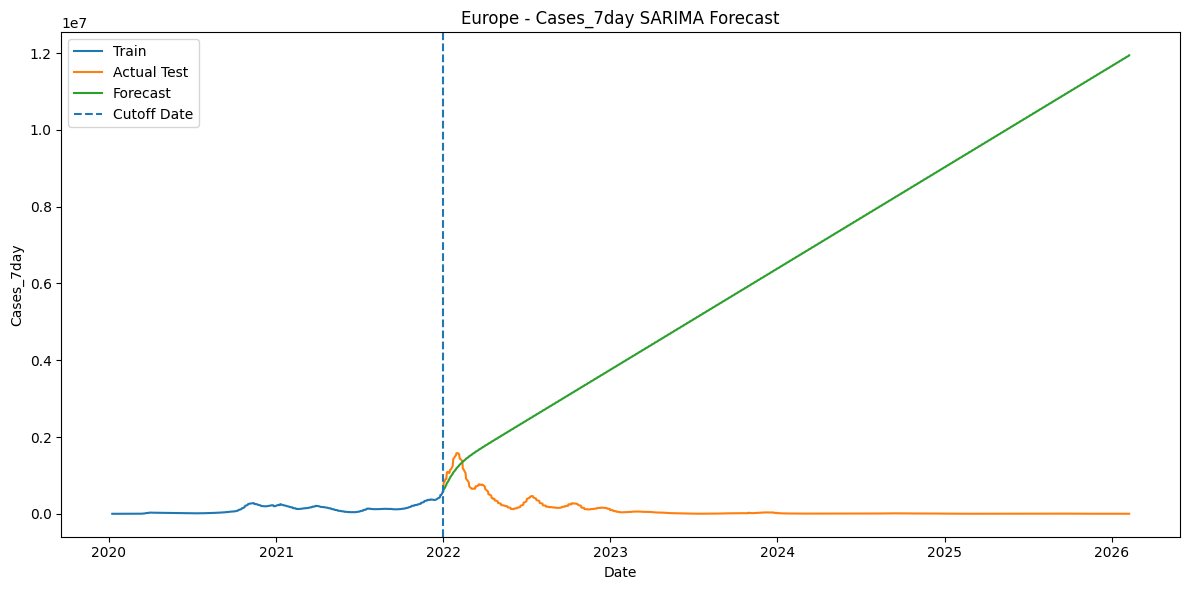

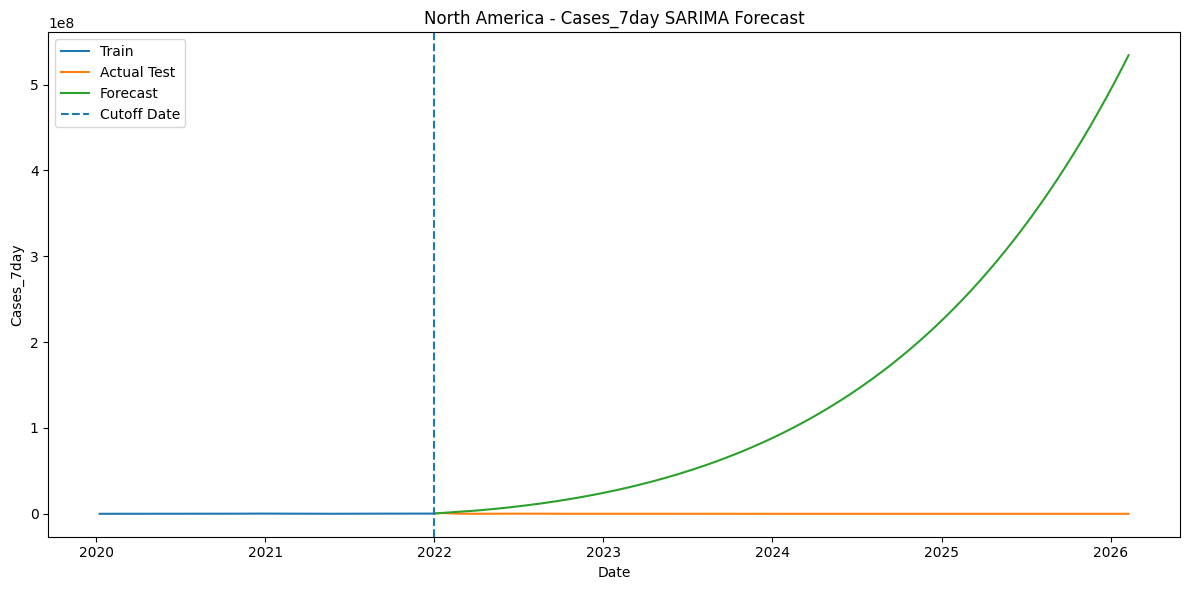

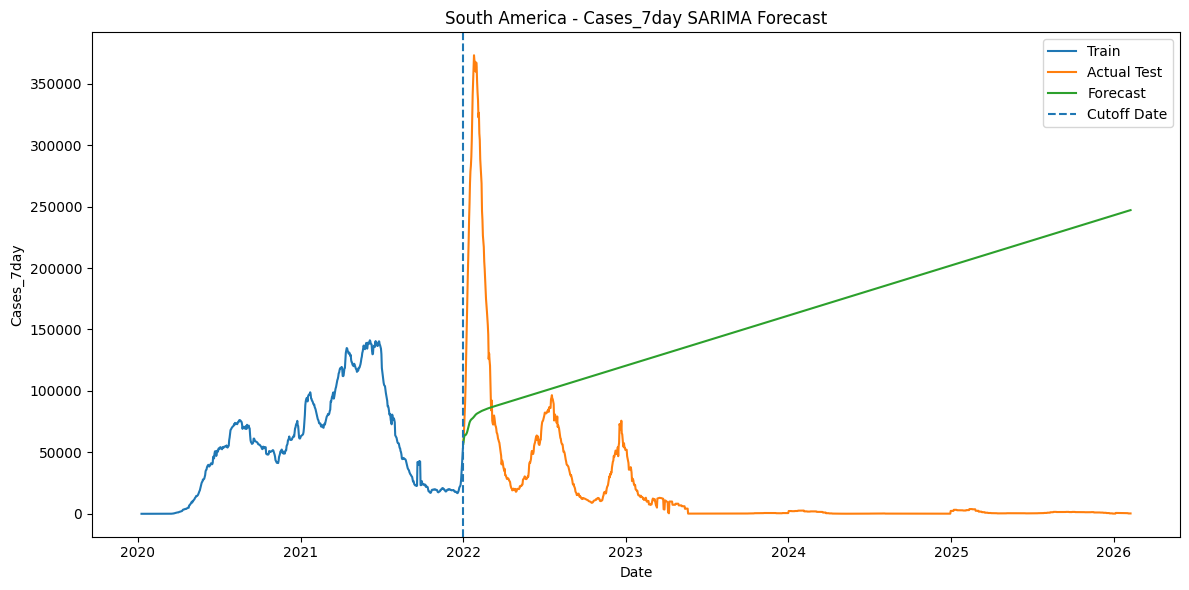

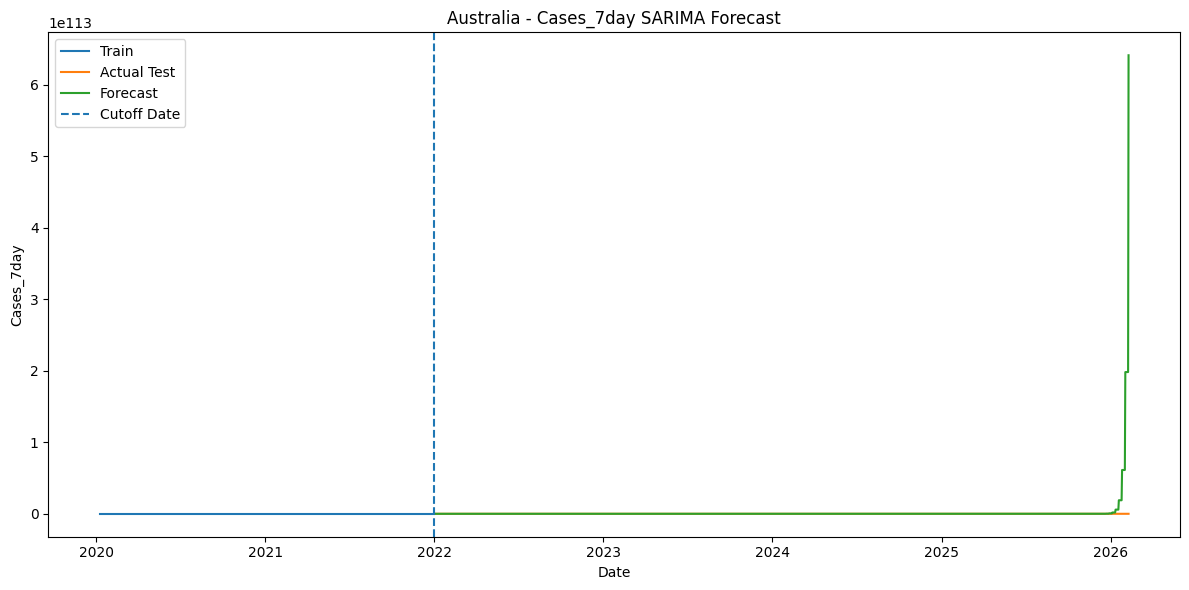


Running SARIMA for deaths...


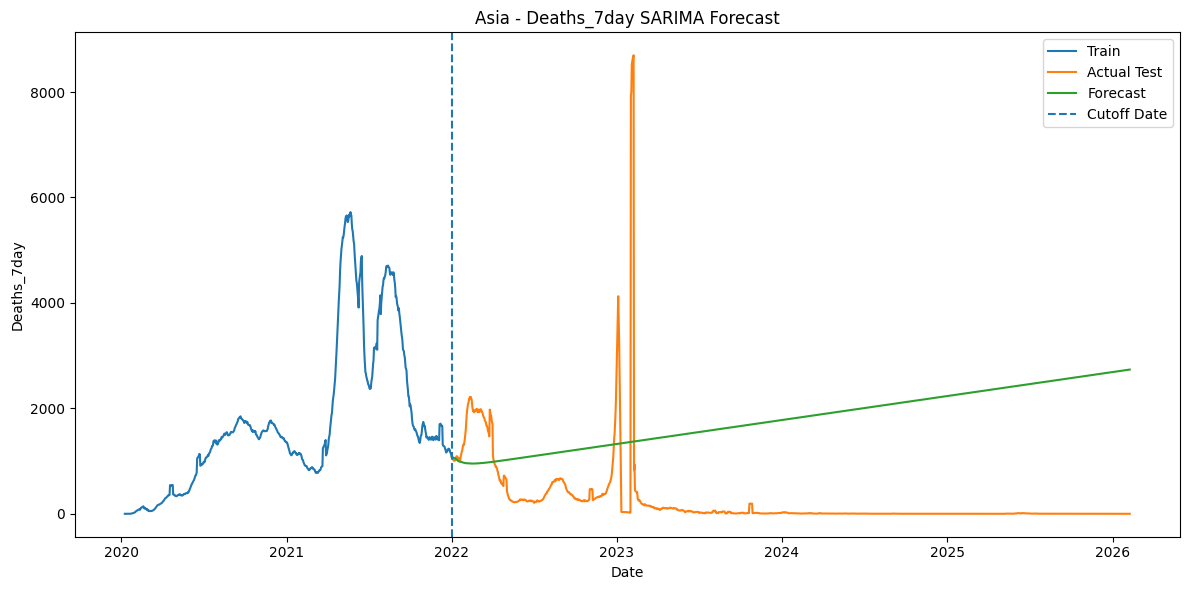

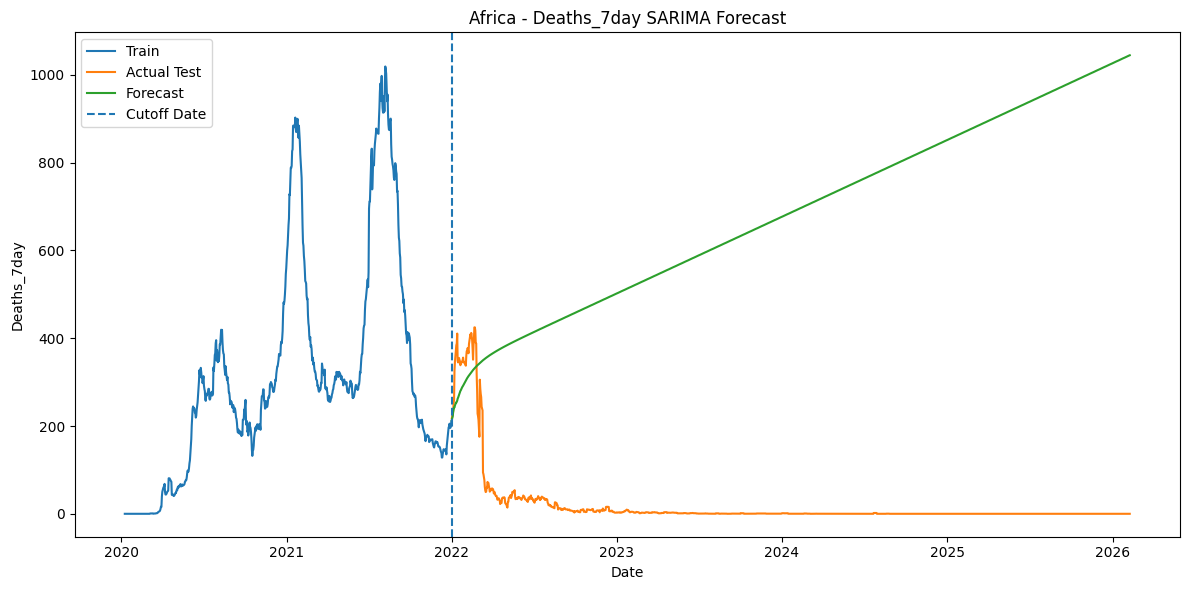

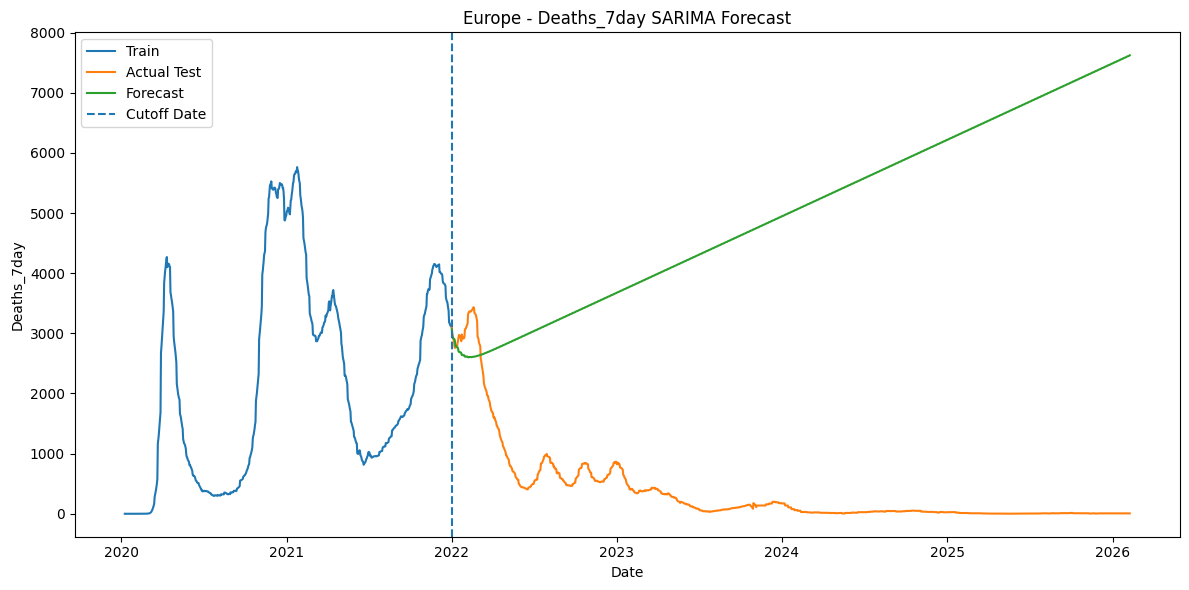

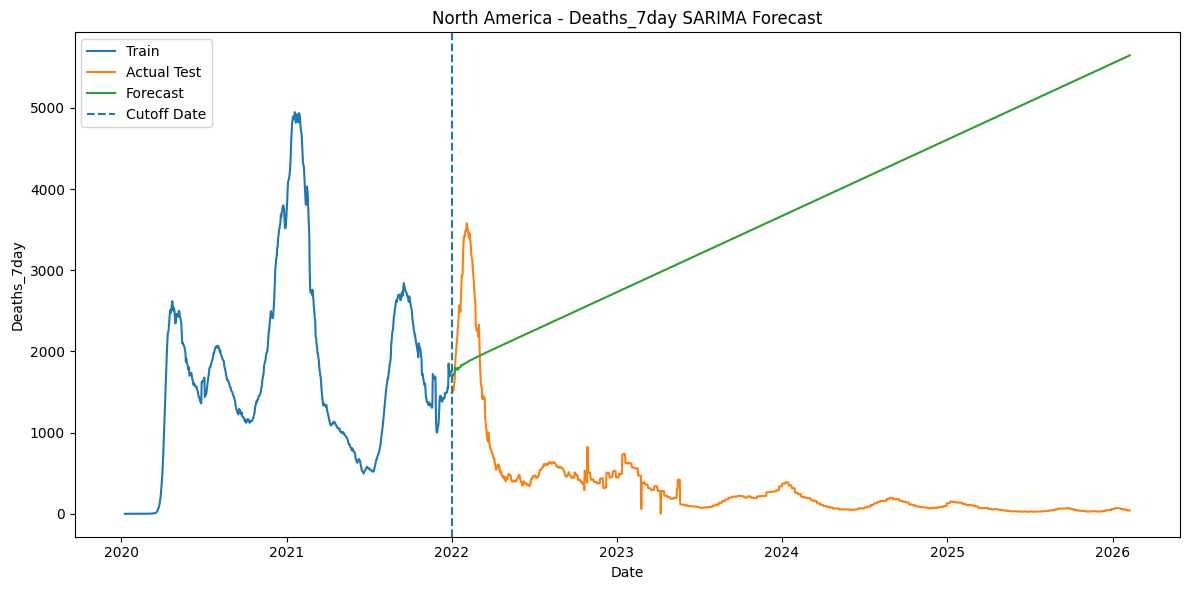

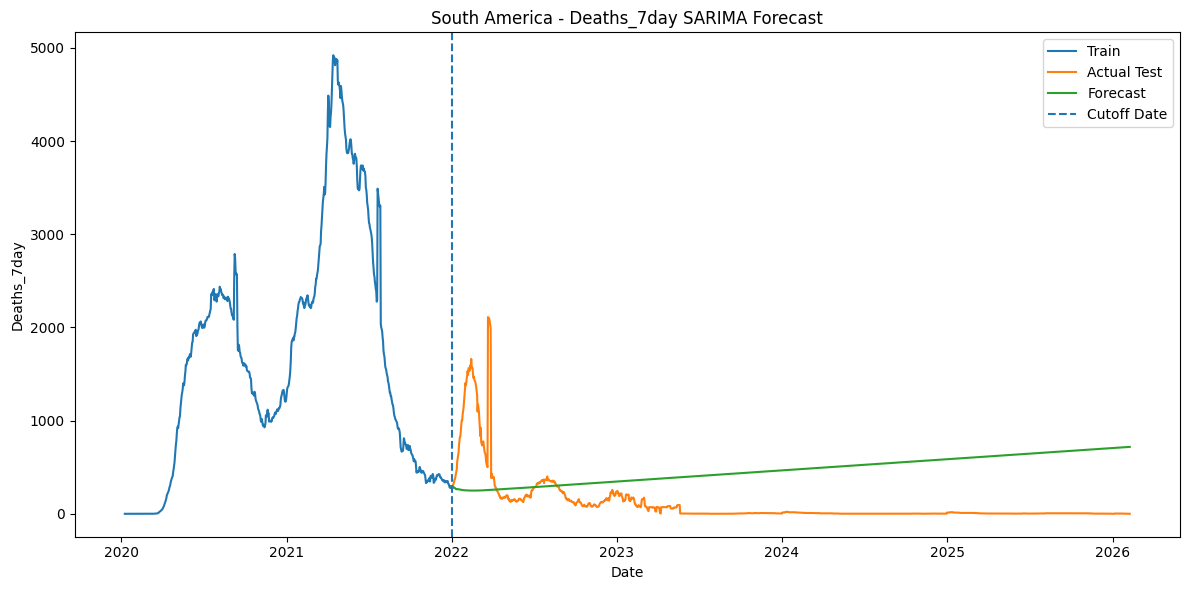

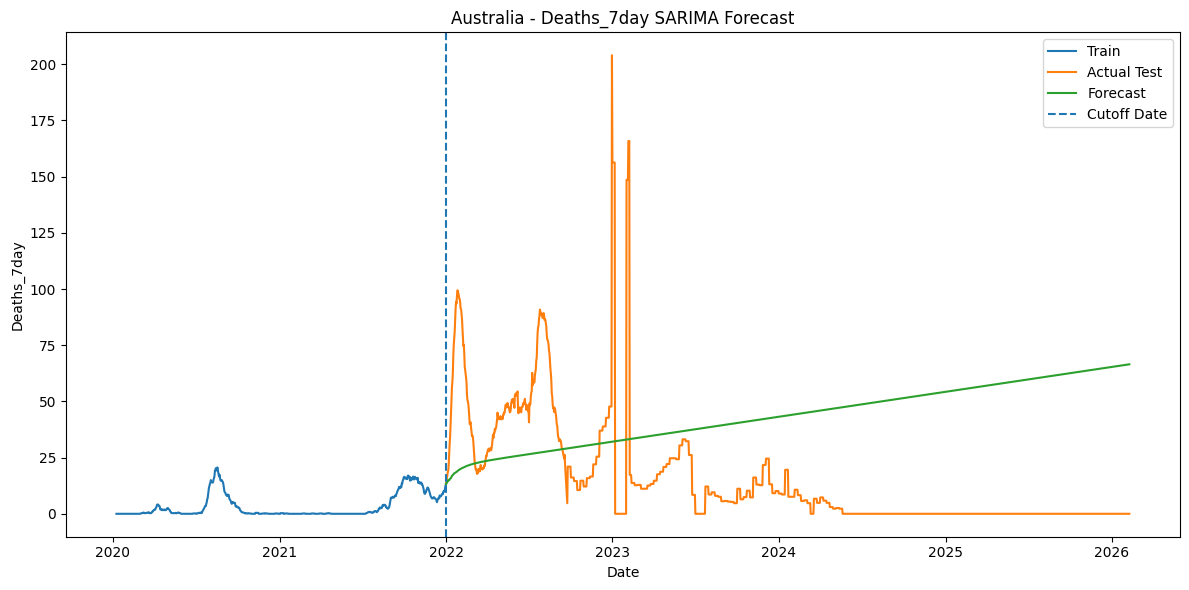

In [62]:
if __name__ == "__main__": # generates all plots (EDA + Analysis) and SARIMA analysis
    print("\nRunning EDA plots...")
    plot_regional_rolling_cases(df, REGION_NAME_MAP)
    plot_regional_rolling_deaths(df, REGION_NAME_MAP)
    plot_distribution_metrics(df)

    print("\nRunning SARIMA for cases...")
    cases_results = run_all_regions(
        data=df,
        region_map=REGION_NAME_MAP,
        target_col="Cases_7day",
        cutoff_date=CUTOFF_DATE,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        make_plots=True
    )

    print("\nRunning SARIMA for deaths...")
    deaths_results = run_all_regions(
        data=df,
        region_map=REGION_NAME_MAP,
        target_col="Deaths_7day",
        cutoff_date=CUTOFF_DATE,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        make_plots=True
    )

In [63]:
cases_results_df = results_to_dataframe(cases_results)
deaths_results_df = results_to_dataframe(deaths_results)

In [64]:
print("\nCases Comparison Table:")
print(cases_results_df) #cases results


Cases Comparison Table:
          Region      Target            MAE           RMSE             R2  \
0           Asia  Cases_7day   6.696585e+05   8.122973e+05  -1.467470e+00   
1         Africa  Cases_7day   9.071028e+04   9.610046e+04  -1.964014e+02   
2         Europe  Cases_7day   6.419135e+06   7.209284e+06  -7.625880e+02   
3  North America  Cases_7day   1.486136e+08   2.094302e+08  -3.122241e+06   
4  South America  Cases_7day   1.562664e+05   1.684062e+05  -9.458203e+00   
5      Australia  Cases_7day  1.766446e+111  2.183998e+112 -2.141229e+216   

   Avg_Predicted_minus_Actual  Total_Predicted_minus_Actual  
0                5.177872e+05                  7.766807e+08  
1                9.069500e+04                  1.360425e+08  
2                6.406084e+06                  9.609126e+09  
3                1.486118e+08                  2.229177e+11  
4                1.434712e+05                  2.152068e+08  
5               1.766446e+111                 2.649669e+114  


In [65]:
print("\nDeaths Comparison Table:")
print(deaths_results_df) # deaths results


Deaths Comparison Table:
          Region       Target          MAE         RMSE         R2  \
0           Asia  Deaths_7day  1721.314909  1891.210206  -5.433514   
1         Africa  Deaths_7day   668.277904   710.197550 -98.357992   
2         Europe  Deaths_7day  4685.731657  5072.201628 -53.039223   
3  North America  Deaths_7day  3456.438149  3708.949468 -44.442129   
4  South America  Deaths_7day   460.887150   521.405541  -2.427389   
5      Australia  Deaths_7day    40.066307    45.272941  -2.277077   

   Avg_Predicted_minus_Actual  Total_Predicted_minus_Actual  
0                 1549.825791                  2.324739e+06  
1                  663.449780                  9.951747e+05  
2                 4652.593517                  6.978890e+06  
3                 3386.917103                  5.080376e+06  
4                  361.214045                  5.418211e+05  
5                   28.361053                  4.254158e+04  


In [66]:
cases_results_df.to_csv(os.path.join(OUTPUT_DIR, "cases_results_summary.csv"), index=False)#saves results as CSV
deaths_results_df.to_csv(os.path.join(OUTPUT_DIR, "deaths_results_summary.csv"), index=False)

In [67]:
chi_table_cases, chi_stats_cases = chi_square_effectiveness(cases_results) #does chi-squared analysis for cases
print_chi_square_results("CHI-SQUARE TEST FOR CASES", chi_table_cases, chi_stats_cases)
chi_table_cases.to_csv(os.path.join(OUTPUT_DIR, "chi_square_cases_table.csv"), index=False)

CHI-SQUARE TEST FOR CASES

Contingency table:
          Region  Better  Worse
0           Asia    1338    162
1         Africa    1488     12
2         Europe    1457     43
3  North America    1482     18
4  South America    1436     64
5      Australia    1500      0

Chi-square test results:
Chi2: 368.56909923473984
p-value: 1.755352516072118e-77
dof: 5

Expected counts:
[[1450.16666667   49.83333333]
 [1450.16666667   49.83333333]
 [1450.16666667   49.83333333]
 [1450.16666667   49.83333333]
 [1450.16666667   49.83333333]
 [1450.16666667   49.83333333]]


In [68]:
chi_table_deaths, chi_stats_deaths = chi_square_effectiveness(deaths_results) #does chi-squared analysis for deaths
print_chi_square_results("CHI-SQUARE TEST FOR DEATHS", chi_table_deaths, chi_stats_deaths)
chi_table_deaths.to_csv(os.path.join(OUTPUT_DIR, "chi_square_deaths_table.csv"), index=False)

CHI-SQUARE TEST FOR DEATHS

Contingency table:
          Region  Better  Worse
0           Asia    1393    107
1         Africa    1445     55
2         Europe    1441     59
3  North America    1446     54
4  South America    1354    146
5      Australia    1227    273

Chi-square test results:
Chi2: 341.3975939062834
p-value: 1.2444418504567523e-71
dof: 5

Expected counts:
[[1384.33333333  115.66666667]
 [1384.33333333  115.66666667]
 [1384.33333333  115.66666667]
 [1384.33333333  115.66666667]
 [1384.33333333  115.66666667]
 [1384.33333333  115.66666667]]
